In [ ]:
pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import struct
import os
from ucimlrepo import fetch_ucirepo

support2 = fetch_ucirepo(id=880)
X = support2.data.features
y = support2.data.targets

df = pd.concat([X, y], axis=1)
print(f"Shape: {df.shape}")
print("Variables:\n", support2.variables)
print("Metadata:\n", support2.metadata)

Shape: (9105, 45)
Variables:
         name     role         type      demographic  \
0         id       ID      Integer             None   
1        age  Feature   Continuous              Age   
2      death   Target   Continuous             None   
3        sex  Feature  Categorical              Sex   
4   hospdead   Target       Binary             None   
5       slos    Other   Continuous             None   
6     d.time    Other   Continuous             None   
7    dzgroup  Feature  Categorical             None   
8    dzclass  Feature  Categorical             None   
9     num.co  Feature   Continuous             None   
10       edu  Feature  Categorical  Education Level   
11    income  Feature  Categorical           Income   
12     scoma  Feature   Continuous             None   
13   charges  Feature   Continuous             None   
14    totcst  Feature   Continuous             None   
15   totmcst  Feature   Continuous             None   
16   avtisst  Feature   Continuous 

In [ ]:
# Sensitive PIR columns
pir_cols = ['scoma', 'meanbp', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea',
            'sod', 'ph', 'glucose', 'bun', 'wblc', 'urine', 'num.co', 'dzgroup',
            'ca', 'diabetes', 'dementia', 'age', 'sex', 'race', 'income', 'edu', 'death']

# Filtering available cols only
available_cols = [col for col in pir_cols if col in df.columns]
df_pir = df[available_cols].copy()
print(f"PIR cols: {len(available_cols)}/{len(pir_cols)} → {df_pir.shape}")

PIR cols: 26/26 → (9105, 26)


In [ ]:
df_pir.head()

,scoma,meanbp,hrt,resp,temp,pafi,alb,bili,crea,sod,...,dzgroup,ca,diabetes,dementia,age,sex,race,income,edu,death
0,0.0,97.0,69.0,22.0,36.00000,388.00000,1.799805,0.199982,1.199951,141.0,...,6.0,0.0,0.0,0.0,62.84998,1.0,4.0,$11-$25k,11.0,0
1,44.0,43.0,112.0,34.0,34.59375,98.00000,2.899902,0.899902,5.500000,132.0,...,3.0,1.0,0.0,0.0,60.33899,0.0,5.0,$11-$25k,12.0,1
2,0.0,70.0,88.0,28.0,37.39844,231.65625,2.899902,2.199707,2.000000,134.0,...,3.0,1.0,0.0,0.0,52.74698,0.0,5.0,under $11k,12.0,1
3,0.0,75.0,88.0,32.0,35.00000,224.00000,2.899902,0.899902,0.799927,139.0,...,6.0,0.0,0.0,0.0,42.38498,0.0,5.0,under $11k,11.0,1
4,26.0,59.0,112.0,20.0,37.89844,173.31250,2.899902,0.899902,0.799927,143.0,...,0.0,1.0,0.0,0.0,79.88495,0.0,5.0,NaN,NaN,0


In [ ]:
print(df_pir.isnull().sum())

scoma          1
meanbp         1
hrt            1
resp           1
temp           1
pafi        2325
alb         3372
bili        2601
crea          67
sod            1
ph          2284
glucose     4500
bun         4352
wblc         212
urine       4862
num.co         0
dzgroup        0
ca             0
diabetes       0
dementia       0
age            0
sex            0
race          42
income      2982
edu         1634
death          0
dtype: int64


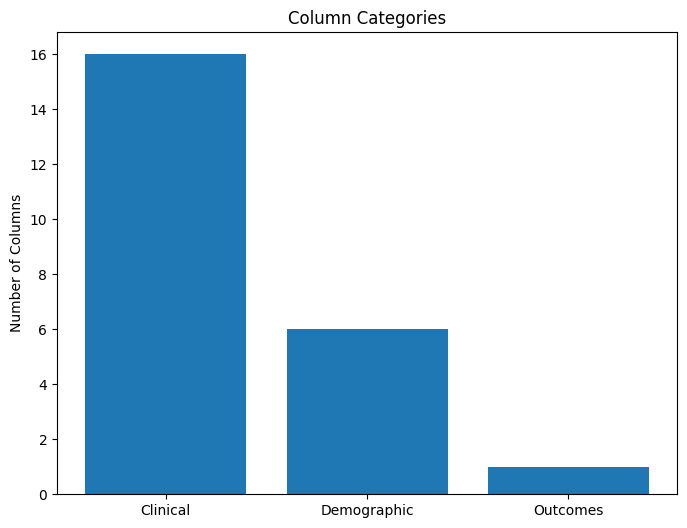

In [ ]:
# Defining categories based on columns
clinical_cols = ['scoma', 'meanbp', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'wblc', 'urine', 'num.co']  # 16
demo_cols = ['age', 'sex', 'race', 'income', 'edu', 'ca']
outcome_cols = ['death']

categories = {
    'Clinical': len(clinical_cols),
    'Demographic': len(demo_cols),
    'Outcomes': len(outcome_cols)
}

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.bar(categories.keys(), categories.values())
plt.title('Column Categories')
plt.ylabel('Number of Columns')
plt.show()

In [ ]:
dfpir_before = df_pir.copy()
missing_before = dfpir_before.isnull().sum()

In [ ]:
# Encoding all categoricals (strings to ints)
cat_cols = ['dzgroup', 'ca', 'diabetes', 'dementia', 'sex', 'race', 'income']
for col in cat_cols:
    if col in df_pir:
        # NaN -> 'MISSING'
        df_pir[col] = pd.Categorical(
            df_pir[col].astype(str).fillna('MISSING')
        ).codes.astype(np.float32)

# Impute numerics
num_cols = ['scoma', 'meanbp', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili',
            'crea', 'sod', 'ph', 'glucose', 'bun', 'wblc', 'urine', 'num.co',
            'age', 'death']  # Pure numbers per UCI
for col in df_pir.columns:
    if col in num_cols:
        df_pir[col] = df_pir[col].fillna(df_pir[col].median())
    else:
        df_pir[col] = df_pir[col].fillna(-1.0)  # As categoricals are already encoded

# Final uniform float32
df_pir = df_pir.astype(np.float32)
print(df_pir.dtypes.value_counts())
print("income sample:", df_pir['income'].unique()[:10])

float32    26
Name: count, dtype: int64
income sample: [0. 4. 3. 1. 2.]


In [ ]:
print(df_pir.isnull().sum())

scoma       0
meanbp      0
hrt         0
resp        0
temp        0
pafi        0
alb         0
bili        0
crea        0
sod         0
ph          0
glucose     0
bun         0
wblc        0
urine       0
num.co      0
dzgroup     0
ca          0
diabetes    0
dementia    0
age         0
sex         0
race        0
income      0
edu         0
death       0
dtype: int64


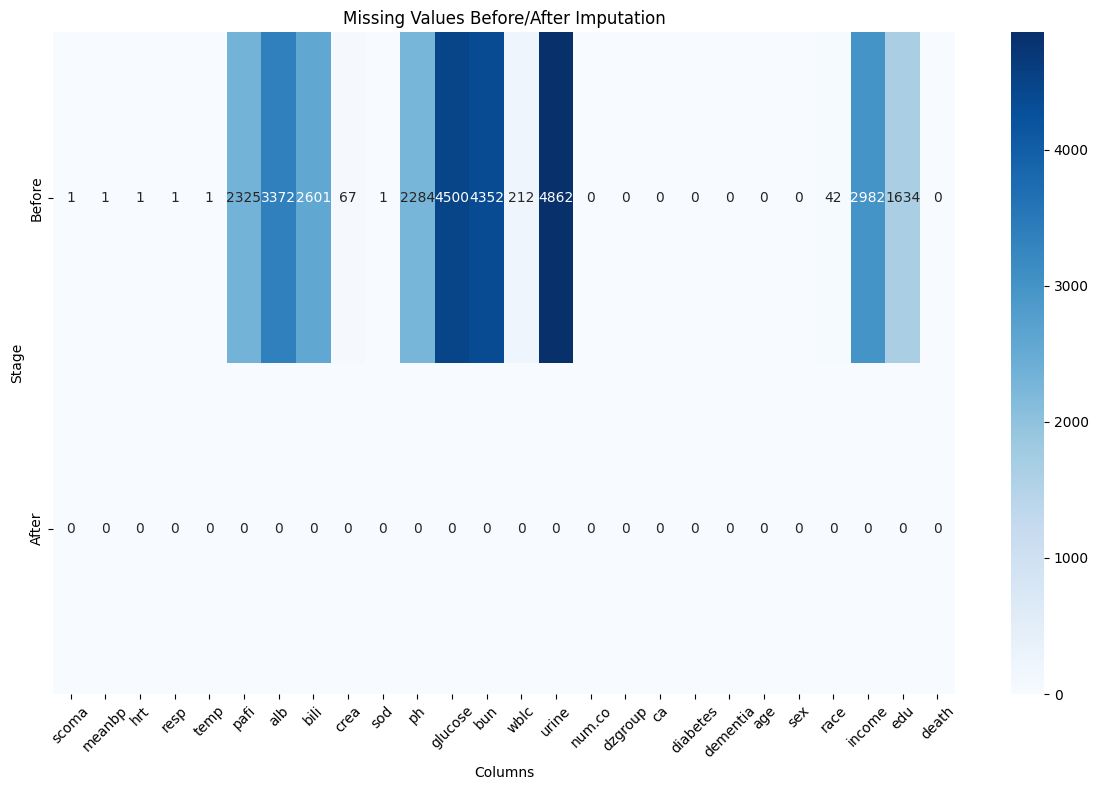

In [ ]:
import seaborn as sns
import pandas as pd

# After imputation, all missing=0
missing_after = df_pir.isnull().sum()

# Comparison DataFrame
missing_df = pd.DataFrame({
    'Before': missing_before,
    'After': missing_after
})

plt.figure(figsize=(12, 8))
sns.heatmap(missing_df.T, annot=True, cmap='Blues', fmt='d')
plt.title('Missing Values Before/After Imputation')
plt.ylabel('Stage')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# For downloading df_pir to system
df_pir.to_csv('df_pir.csv', index=False)
from google.colab import files
files.download('df_pir.csv')

In [ ]:
RECORD_SIZE = 512
N_RECORDS = len(df_pir)

# For XPIR/SealPIR (raw records)
with open('support2_pir.db', 'wb') as f:
    for _, row in df_pir.iterrows():
        buf = bytearray(RECORD_SIZE)
        offset = 0
        for val in row.values.astype(np.float32):  # Uniform float32 (FHE-friendly)
            struct.pack_into('<f', buf, offset, val)
            offset += 4
        f.write(buf)

print(f"XPIR/SealPIR DB: support2_pir.db ({N_RECORDS} x {RECORD_SIZE}B = {N_RECORDS*RECORD_SIZE/1e6:.1f}MB)")

XPIR/SealPIR DB: support2_pir.db (9105 x 512B = 4.7MB)


In [ ]:
# Researchers' queries: Aggregates DB (pad to SAME 26 fields as df_pir)
agg_df = df_pir.groupby('dzgroup')['death'].agg(['mean', 'count']).reset_index()
agg_df['dzgroup_code'] = pd.Categorical(agg_df['dzgroup']).codes

# Pad to 26 cols to match df_pir.columns order
stats_cols = df_pir.columns.tolist()
dummy_stats = pd.DataFrame(0.0, index=agg_df.index, columns=stats_cols)

# Known stats
dummy_stats['dzgroup'] = agg_df['dzgroup_code']
dummy_stats['death'] = agg_df['mean']  # Reuse 'death' slot for mortality rate

RECORD_SIZE_STATS = RECORD_SIZE
with open('support2_stats.db', 'wb') as f:
    for _, row in dummy_stats.iterrows():
        buf = bytearray(RECORD_SIZE_STATS)
        offset = 0
        for val in row.values.astype(np.float32):
            struct.pack_into('<f', buf, offset, val)
            offset += 4
        f.write(buf)

print(f"Stats DB: {len(dummy_stats)} records x 512B")

Stats DB: 8 records x 512B


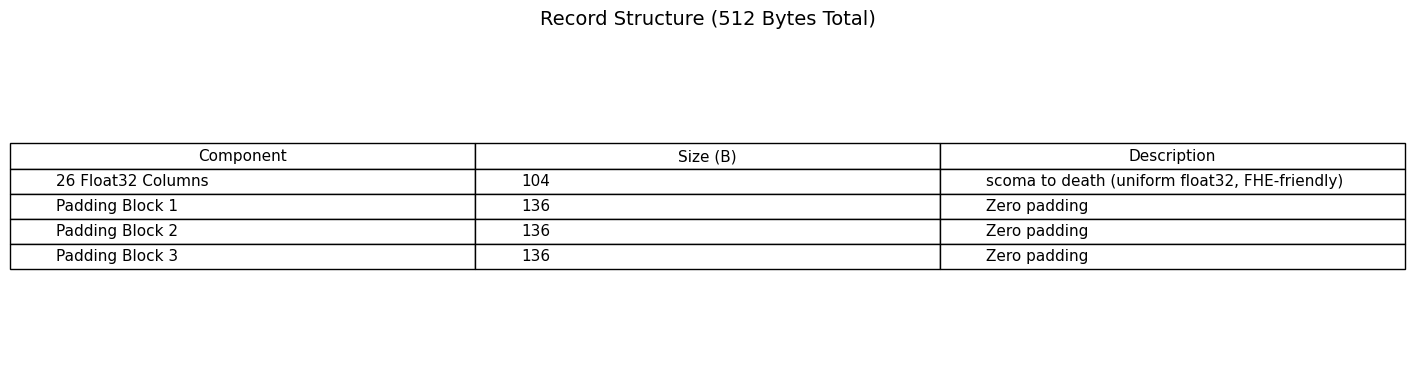

NameError: name 'dfpir' is not defined

In [ ]:
record_data = [
    ['26 Float32 Columns', '104', 'scoma to death (uniform float32, FHE-friendly)'],
    ['Padding Block 1', '136', 'Zero padding'],
    ['Padding Block 2', '136', 'Zero padding'],
    ['Padding Block 3', '136', 'Zero padding']
]
col_labels = ['Component', 'Size (B)', 'Description']

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=record_data,
                 colLabels=col_labels,
                 cellLoc='left',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.5, 1.5)
plt.title('Record Structure (512 Bytes Total)', fontsize=14, pad=20)
plt.show()

print("N_RECORDS:", len(dfpir), "| RECORD_SIZE: 512B | Total DB:", round(len(dfpir)*512/1e6, 1), "MB")[file:1][file:2]